# Ejercicio: Modelos de Regresión Demográfica para México (a partir de 2000)

**Materia:** Tópicos de Big Data  
**Modelos:** Regresión Lineal (RL), Regresión Polinomial Grado 2 (RP), Random Forest Regressor (RF)  
**Dataset:** Our World in Data (OWID) / División de Población de la ONU  
**Periodo histórico:** 2000 – 2023 | **Periodo proyectado:** 2024 – 2100


## 1. Importación de bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor


## 2. Carga y preparación de datos

In [2]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"
posibles_rutas = [
    "births-and-deaths-projected-to-2100.csv",
    "../births-and-deaths-projected-to-2100.csv",
    "U3_1_modelos_ml/births-and-deaths-projected-to-2100.csv"
]

archivo_local = next((p for p in posibles_rutas if os.path.exists(p)), None)

if archivo_local:
    print(f"Cargando dataset local: {archivo_local}")
    df = pd.read_csv(archivo_local)
else:
    print("Descargando dataset desde Our World in Data...")
    df = pd.read_csv(url, storage_options={"User-Agent": "Our World In Data data fetch/1.0"})

df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})

df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])

anios_futuros = np.arange(2024, 2101).reshape(-1, 1)
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])


Cargando dataset local: ../births-and-deaths-projected-to-2100.csv


## 3. Filtrar datos de México a partir del año 2000

In [3]:
df_mexico = df[df["Entity"] == "Mexico"].copy()
df_mexico_historico = df_mexico[(df_mexico["Year"] >= 2000) & (df_mexico["Year"] <= 2023)].copy()
df_mexico_proyectado = df_mexico[df_mexico["Year"] > 2023].copy()

print("México Histórico (>= 2000) ->", df_mexico_historico.shape, "| Años:", df_mexico_historico["Year"].min(), "a", df_mexico_historico["Year"].max())
print("México Proyectado          ->", df_mexico_proyectado.shape, "| Años:", df_mexico_proyectado["Year"].min(), "a", df_mexico_proyectado["Year"].max())


México Histórico (>= 2000) -> (24, 9) | Años: 2000 a 2023
México Proyectado          -> (77, 9) | Años: 2024 a 2100


## 4. Exploración visual histórica (2000 - 2023)

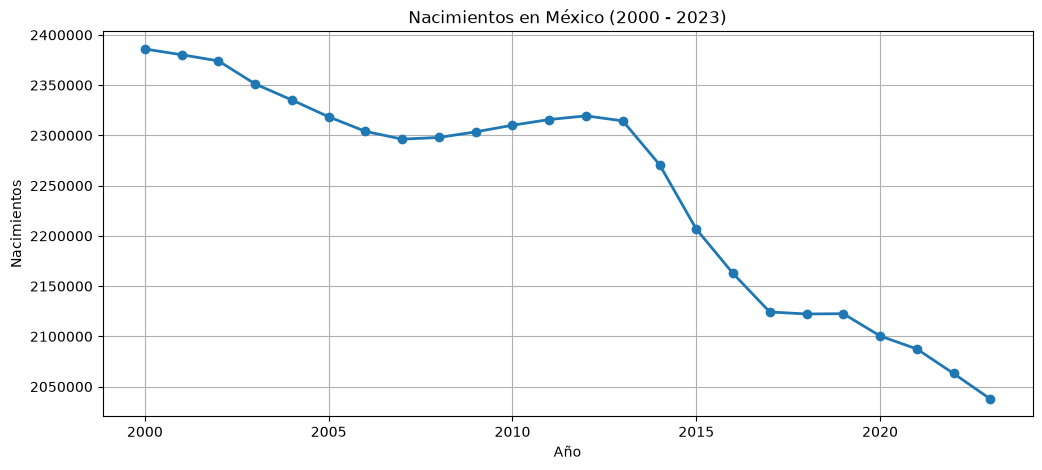

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df_mexico_historico["Year"], df_mexico_historico["births"], marker="o", color="tab:blue", linewidth=2)
plt.title("Nacimientos en México (2000 - 2023)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid(True)
plt.show()


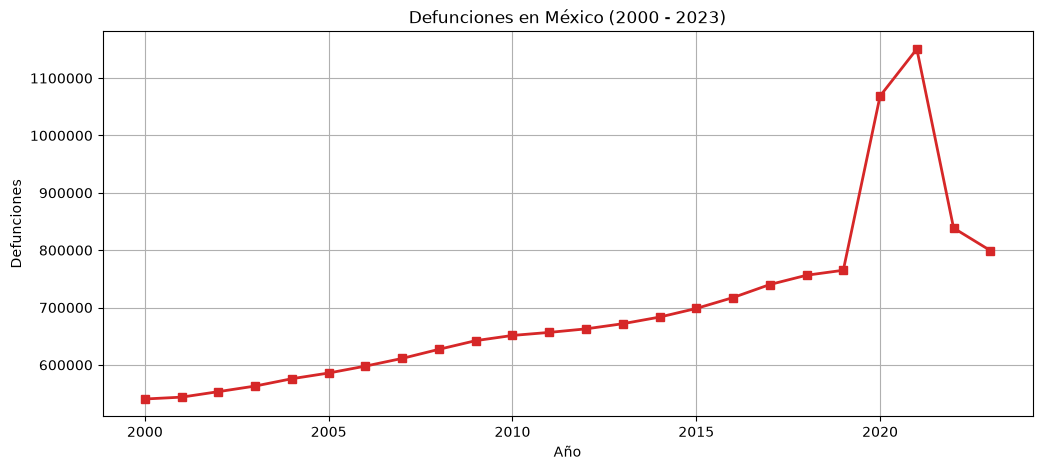

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df_mexico_historico["Year"], df_mexico_historico["deaths"], marker="s", color="tab:red", linewidth=2)
plt.title("Defunciones en México (2000 - 2023)")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid(True)
plt.show()


## 5. Modelado de Nacimientos en México (RL, RP, RF)

In [6]:
X_mex = df_mexico_historico[["Year"]]
y_mex_births = df_mexico_historico["births"]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_mex_poly = poly.fit_transform(X_mex)
X_mex_futuro_poly = poly.transform(X_futuro)

# RL
lr_mex_births = LinearRegression().fit(X_mex, y_mex_births)
pred_lr_mex_b_hist = lr_mex_births.predict(X_mex)
pred_lr_mex_b_fut = lr_mex_births.predict(X_futuro)

# RP
pr_mex_births = LinearRegression().fit(X_mex_poly, y_mex_births)
pred_pr_mex_b_hist = pr_mex_births.predict(X_mex_poly)
pred_pr_mex_b_fut = pr_mex_births.predict(X_mex_futuro_poly)

# RF
rf_mex_births = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_mex, y_mex_births)
pred_rf_mex_b_hist = rf_mex_births.predict(X_mex)
pred_rf_mex_b_fut = rf_mex_births.predict(X_futuro)


### 5.1 Gráficas individuales y comparativas para Nacimientos

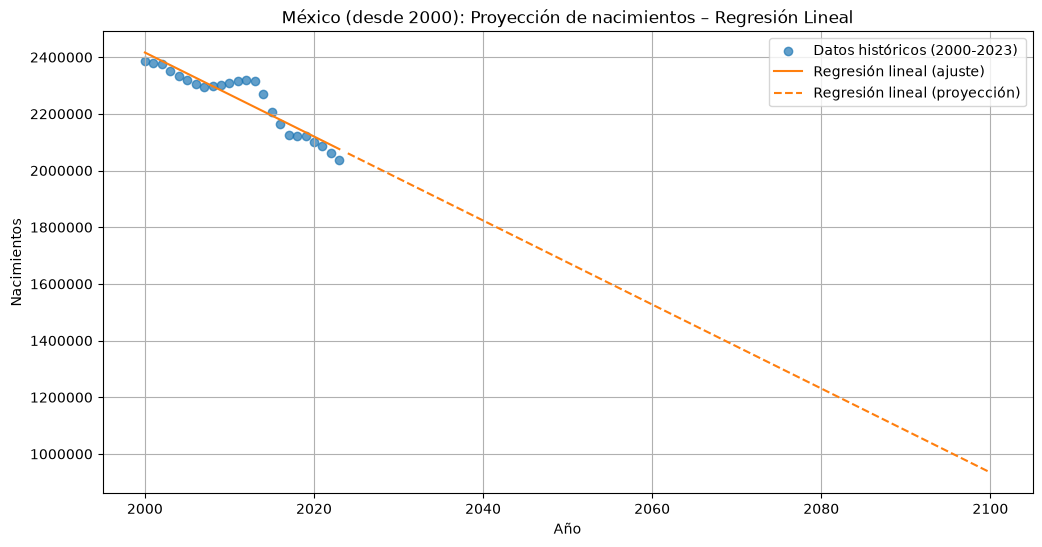

In [7]:
plt.figure(figsize=(12, 6))
plt.scatter(df_mexico_historico["Year"], df_mexico_historico["births"], label="Datos históricos (2000-2023)", alpha=0.7)
plt.plot(df_mexico_historico["Year"], pred_lr_mex_b_hist, color="tab:orange", label="Regresión lineal (ajuste)")
plt.plot(anios_futuros.flatten(), pred_lr_mex_b_fut, color="tab:orange", linestyle="--", label="Regresión lineal (proyección)")
plt.title("México (desde 2000): Proyección de nacimientos – Regresión Lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


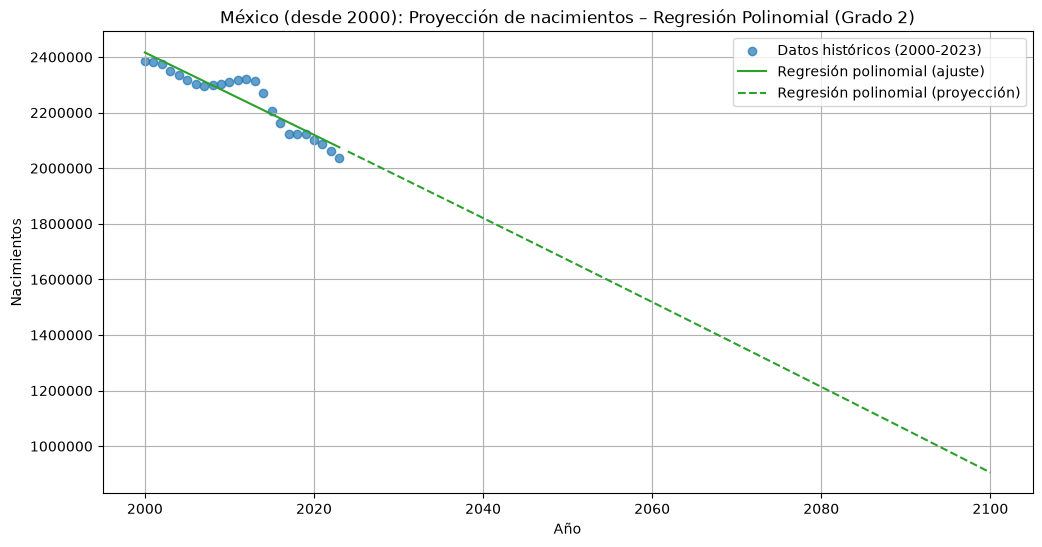

In [8]:
plt.figure(figsize=(12, 6))
plt.scatter(df_mexico_historico["Year"], df_mexico_historico["births"], label="Datos históricos (2000-2023)", alpha=0.7)
plt.plot(df_mexico_historico["Year"], pred_pr_mex_b_hist, color="tab:green", label="Regresión polinomial (ajuste)")
plt.plot(anios_futuros.flatten(), pred_pr_mex_b_fut, color="tab:green", linestyle="--", label="Regresión polinomial (proyección)")
plt.title("México (desde 2000): Proyección de nacimientos – Regresión Polinomial (Grado 2)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


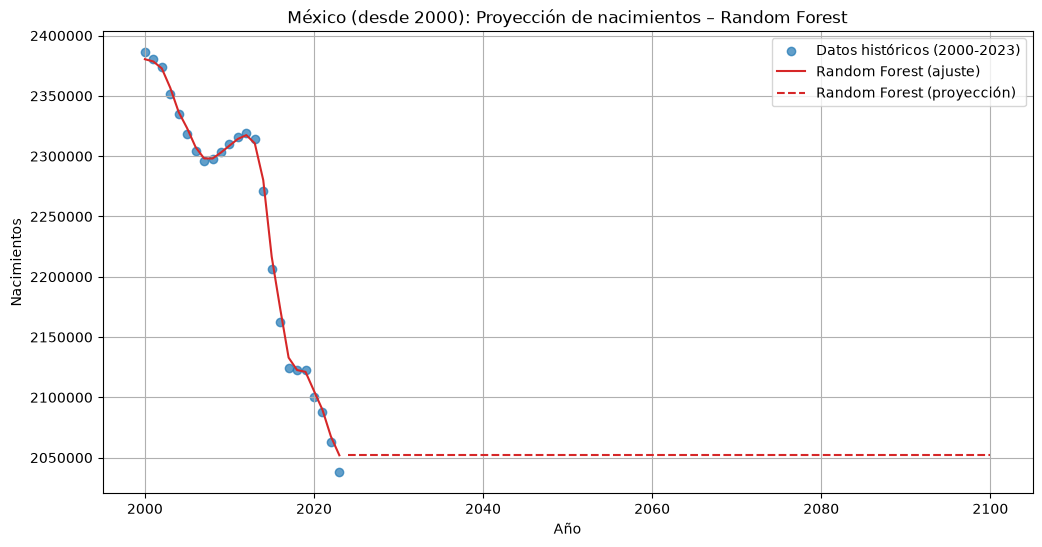

In [9]:
plt.figure(figsize=(12, 6))
plt.scatter(df_mexico_historico["Year"], df_mexico_historico["births"], label="Datos históricos (2000-2023)", alpha=0.7)
plt.plot(df_mexico_historico["Year"], pred_rf_mex_b_hist, color="tab:red", label="Random Forest (ajuste)")
plt.plot(anios_futuros.flatten(), pred_rf_mex_b_fut, color="tab:red", linestyle="--", label="Random Forest (proyección)")
plt.title("México (desde 2000): Proyección de nacimientos – Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


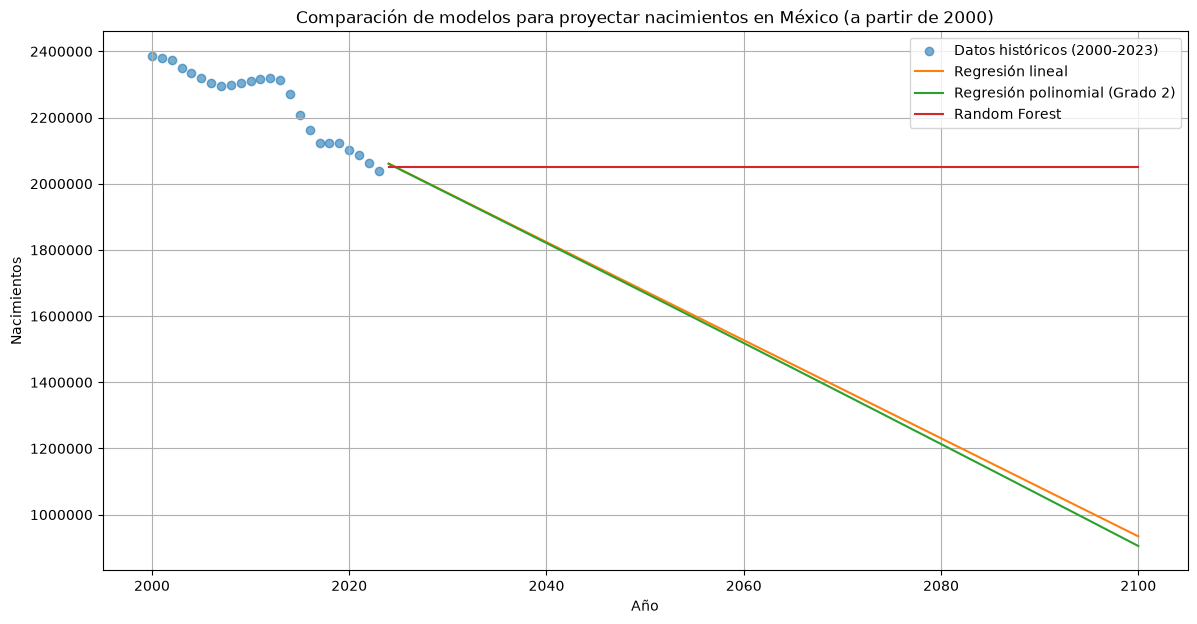

In [10]:
plt.figure(figsize=(14, 7))
plt.scatter(df_mexico_historico["Year"], df_mexico_historico["births"], label="Datos históricos (2000-2023)", alpha=0.6)
plt.plot(anios_futuros.flatten(), pred_lr_mex_b_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_mex_b_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_mex_b_fut, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar nacimientos en México (a partir de 2000)")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


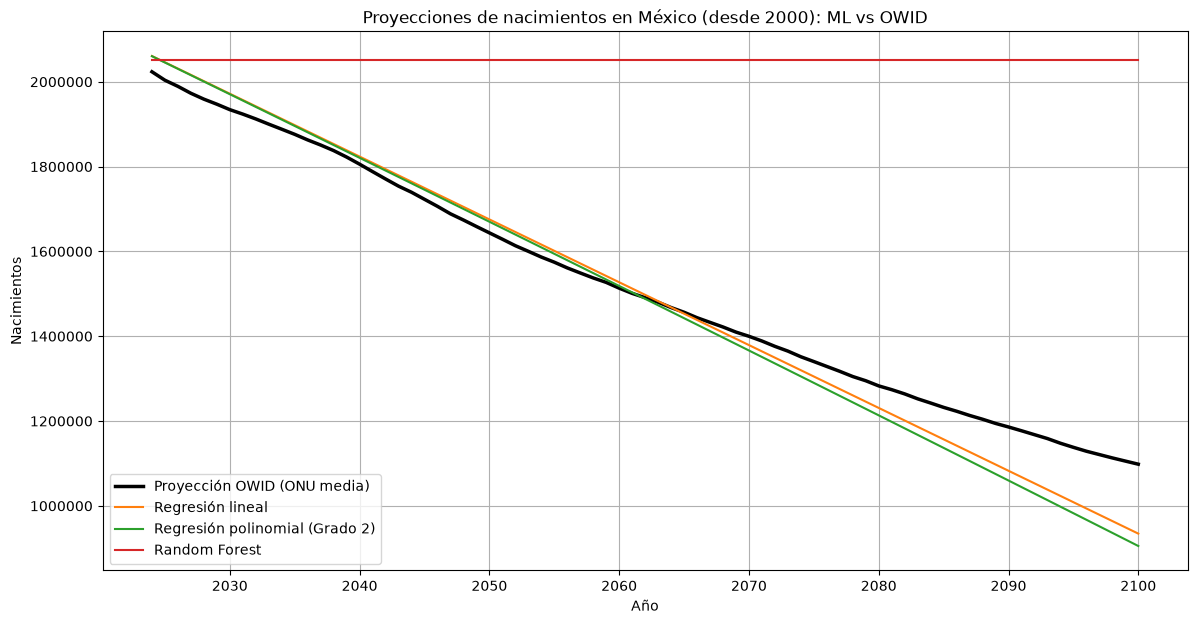

In [11]:
plt.figure(figsize=(14, 7))
plt.plot(df_mexico_proyectado["Year"], df_mexico_proyectado["births"], color="black", linewidth=2.5, label="Proyección OWID (ONU media)")
plt.plot(anios_futuros.flatten(), pred_lr_mex_b_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_mex_b_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_mex_b_fut, color="tab:red", label="Random Forest")
plt.title("Proyecciones de nacimientos en México (desde 2000): ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


## 6. Modelado de Defunciones en México (RL, RP, RF)

In [12]:
y_mex_deaths = df_mexico_historico["deaths"]

# RL
lr_mex_deaths = LinearRegression().fit(X_mex, y_mex_deaths)
pred_lr_mex_d_hist = lr_mex_deaths.predict(X_mex)
pred_lr_mex_d_fut = lr_mex_deaths.predict(X_futuro)

# RP
pr_mex_deaths = LinearRegression().fit(X_mex_poly, y_mex_deaths)
pred_pr_mex_d_hist = pr_mex_deaths.predict(X_mex_poly)
pred_pr_mex_d_fut = pr_mex_deaths.predict(X_mex_futuro_poly)

# RF
rf_mex_deaths = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_mex, y_mex_deaths)
pred_rf_mex_d_hist = rf_mex_deaths.predict(X_mex)
pred_rf_mex_d_fut = rf_mex_deaths.predict(X_futuro)


### 6.1 Gráficas comparativas para Defunciones

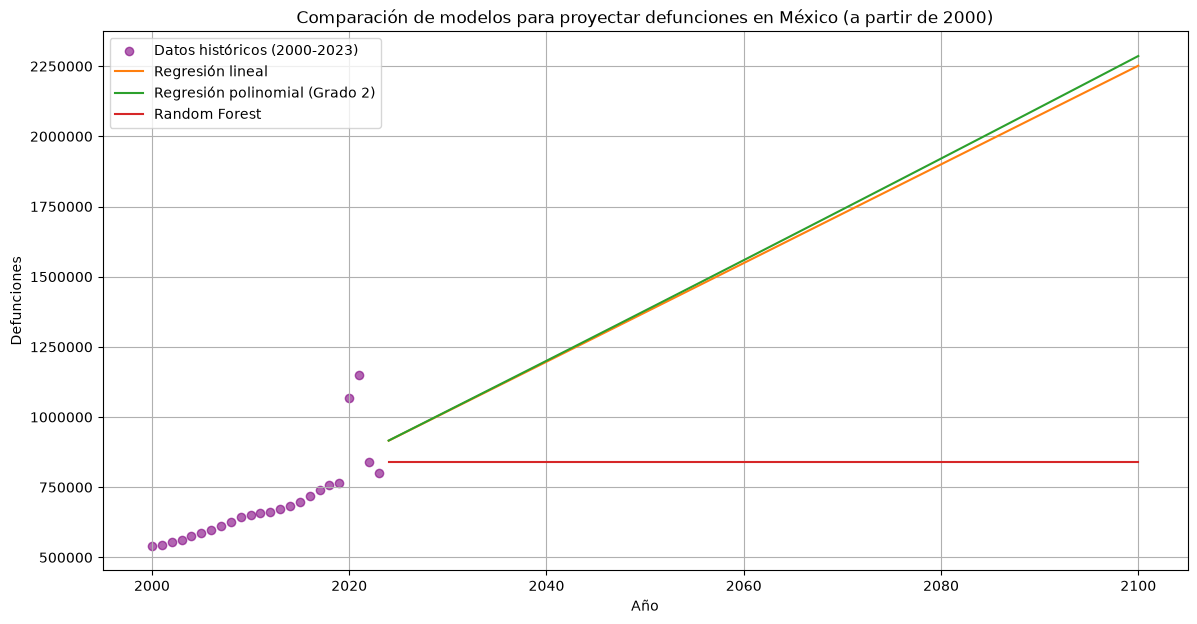

In [13]:
plt.figure(figsize=(14, 7))
plt.scatter(df_mexico_historico["Year"], df_mexico_historico["deaths"], label="Datos históricos (2000-2023)", alpha=0.6, color="purple")
plt.plot(anios_futuros.flatten(), pred_lr_mex_d_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_mex_d_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_mex_d_fut, color="tab:red", label="Random Forest")
plt.title("Comparación de modelos para proyectar defunciones en México (a partir de 2000)")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


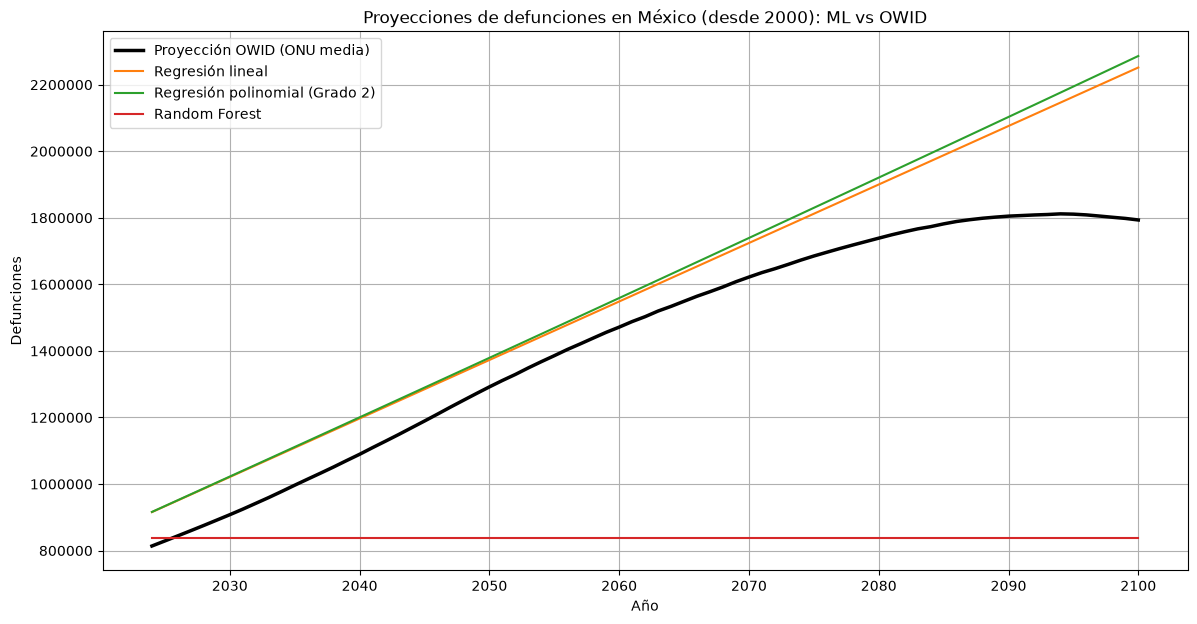

In [14]:
plt.figure(figsize=(14, 7))
plt.plot(df_mexico_proyectado["Year"], df_mexico_proyectado["deaths"], color="black", linewidth=2.5, label="Proyección OWID (ONU media)")
plt.plot(anios_futuros.flatten(), pred_lr_mex_d_fut, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_pr_mex_d_fut, color="tab:green", label="Regresión polinomial (Grado 2)")
plt.plot(anios_futuros.flatten(), pred_rf_mex_d_fut, color="tab:red", label="Random Forest")
plt.title("Proyecciones de defunciones en México (desde 2000): ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid(True)
plt.show()


## 7. Resumen numérico comparativo

In [15]:
anios_tabla = [2030, 2050, 2075, 2100]
indice = anios_futuros.flatten()

def construir_tabla_resumen(df_proy, col, lineal, polinomial, rf):
    tabla = pd.DataFrame({
        "OWID (ONU)": df_proy.set_index("Year")[col].reindex(indice).to_numpy(),
        "Regresión Lineal": lineal,
        "Regresión Polinomial": polinomial,
        "Random Forest": rf
    }, index=indice)
    tabla.index.name = "Año"
    return tabla.loc[anios_tabla]

print("MÉXICO (DESDE 2000) - Proyección de Nacimientos:")
display(construir_tabla_resumen(df_mexico_proyectado, "births", pred_lr_mex_b_fut, pred_pr_mex_b_fut, pred_rf_mex_b_fut).style.format("{:,.0f}"))

print("\nMÉXICO (DESDE 2000) - Proyección de Defunciones:")
display(construir_tabla_resumen(df_mexico_proyectado, "deaths", pred_lr_mex_d_fut, pred_pr_mex_d_fut, pred_rf_mex_d_fut).style.format("{:,.0f}"))


MÉXICO (DESDE 2000) - Proyección de Nacimientos:


,OWID (ONU),Regresión Lineal,Regresión Polinomial,Random Forest
Año,,,,
2030,"1,934,285","1,971,876","1,970,689","2,051,955"
2050,"1,643,767","1,675,481","1,669,982","2,051,955"
2075,"1,340,246","1,304,988","1,289,953","2,051,955"
2100,"1,098,210","934,494","905,317","2,051,955"



MÉXICO (DESDE 2000) - Proyección de Defunciones:


,OWID (ONU),Regresión Lineal,Regresión Polinomial,Random Forest
Año,,,,
2030,"907,843","1,021,129","1,022,528","838,793"
2050,"1,291,889","1,372,705","1,379,209","838,793"
2075,"1,685,181","1,812,175","1,829,978","838,793"
2100,"1,793,462","2,251,646","2,286,211","838,793"
